# Algorithm / Overview

## Simple system (Questions 1–4): constant neutron flux

**Goal:** Solve the depletion of 5 nuclides (U-238, U-235, Pu-239, X, Y) under a constant flux

$$
\Phi = 10^{13}\ \mathrm{n\,cm^{-2}\,s^{-1}}.
$$

1. **Compute initial concentrations** (homogenized assembly):
   - compute total UO$_2$ mass from geometry and density;
   - convert to number of uranium atoms;
   - apply enrichment (3% atomic fraction);
   - homogenize by dividing by assembly volume.

2. **Build depletion matrix** $A$ for the simple chain (units: $\mathrm{s^{-1}}$):
   - diagonal loss terms: $-\Phi\,\sigma_a$ (and $-\lambda_X$ for nuclide $X$);
   - production terms: U-238 $(n,\gamma)\rightarrow$ Pu-239 and U-235 fission $(\rightarrow X,Y)$.

3. **Analytical solution** for 0–365 days (closed-form for this triangular chain).

4. **Numerical solutions** and requested diagnostics:
   - Forward Euler:
     $$
     N^{n+1} = N^n + \Delta t\,A\,N^n
     $$
   - Matrix exponential (Taylor, 3rd order):
     $$
     N^{n+1} \approx \left(I + B + \frac{B^2}{2} + \frac{B^3}{6}\right)N^n,
     \qquad B = A\,\Delta t
     $$
   - Plots: semilog-y (0–365 days), zoom (0–1 day), relative errors ($\Delta t=1$ min),
     convergence vs $\Delta t$ with QoI $N_X(1\,\mathrm{day})$.

---

## Complex system (Questions 5–6): constant power density

**Goal:** Keep power density constant at

$$
P_0 = 937.5\ \mathrm{W\,cm^{-3}}
$$

by adapting flux in time.

5. Compute $\Phi(t)$ at each step using:

$$
\Phi(t)=\frac{P_0}{\sum_{i\in\{235,238,\mathrm{Pu}\}} \kappa_i\,\sigma_{f,i}\,N_i(t)}.
$$

6. Build $A(\Phi(t))$ including fissions in U-235, U-238 and Pu-239 producing $(X,Y)$ with identical yields.

7. Time integrate with Exp3 ($\Delta t=1$ min) over 180 days and plot $\Phi(t)$ and $N(t)$.


In [2]:

import numpy as np
import math
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140


## Data

In [3]:

# -----------------------
# Units / constants
# -----------------------
BARN_TO_CM2 = 1e-24
NA = 6.02214076e23  # Avogadro [1/mol]

# -----------------------
# Problem data (microscopic XS are in barn)
# -----------------------
nuclides = ["U238", "U235", "Pu239", "X", "Y"]

# Microscopic capture and fission cross sections [barn]
sig_c_b = {"U235": 12.0, "U238": 4.0, "Pu239": 81.0, "X": 5.0e6, "Y": 50.0}
sig_f_b = {"U235": 56.0, "U238": 1.0, "Pu239": 144.0, "X": 0.0, "Y": 0.0}

def sig_a_b(name: str) -> float:
    """Return microscopic absorption cross section σ_a [barn] = σ_c + σ_f."""
    return sig_c_b[name] + sig_f_b[name]

# Convert cross sections to [cm^2]
sig_c = {k: v * BARN_TO_CM2 for k, v in sig_c_b.items()}
sig_f = {k: v * BARN_TO_CM2 for k, v in sig_f_b.items()}
sig_a = {k: sig_a_b(k) * BARN_TO_CM2 for k in sig_c_b.keys()}

# Decay: X has half-life 9 h (Y is stable)
T12_X_s = 9.0 * 3600.0  # [s]
LAMBDA_X = math.log(2.0) / T12_X_s  # [1/s]

# Fission yields (given; used where required)
FY_X = 0.06
FY_Y = 1.94

# Kappa (energy per fission) [J/fission] used in constant-power case
kappa_J = {"U235": 3.24e-11, "U238": 3.32e-11, "Pu239": 3.33e-11, "X": 0.0, "Y": 0.0}


## Question 1 — Initial atomic concentrations (homogenized assembly)

In [10]:

# -----------------------
# Geometry / homogenization
# -----------------------
n_rods = 264
pellet_r_cm = 0.4     # [cm]
rod_h_cm = 400.0      # [cm]
rho_uo2 = 10.4        # [g/cm^3]
pitch_cm = 20.0       # [cm]
enrichment = 0.03     # atomic fraction of U-235

def initial_concentrations_homogenized(enrichment: float = 0.03):
    """Compute homogenized initial concentrations N0 [cm^-3].

    Steps:
      1) fuel volume from rod/pellet geometry
      2) UO2 mass from density
      3) moles -> uranium atoms (1 U per UO2)
      4) homogenize by assembly volume (pitch^2 * height)
      5) split U into U-235/U-238 by enrichment (atomic fraction)

    Returns
    -------
    N0 : dict
        Initial concentrations [cm^-3] for U235, U238, Pu239, X, Y.
    V_fuel : float
        Fuel volume [cm^3].
    V_assy : float
        Assembly volume [cm^3].
    """
    V_fuel = n_rods * math.pi * pellet_r_cm**2 * rod_h_cm
    V_assy = (pitch_cm * pitch_cm) * rod_h_cm

    # Weighted uranium molar mass [g/mol] (approx) and UO2 molar mass [g/mol]
    M_U = enrichment * 235.0 + (1.0 - enrichment) * 238.0
    M_UO2 = M_U + 32.0

    mass_uo2_g = rho_uo2 * V_fuel
    moles_uo2 = mass_uo2_g / M_UO2

    N_U_total = moles_uo2 * NA     # uranium atoms in assembly fuel
    N_U = N_U_total / V_assy       # homogenized (per cm^3 of assembly)

    N0 = {
        "U235": enrichment * N_U,
        "U238": (1.0 - enrichment) * N_U,
        "Pu239": 0.0,
        "X": 0.0,
        "Y": 0.0,
    }
    return N0, V_fuel, V_assy

N0, V_fuel, V_assy = initial_concentrations_homogenized(enrichment)

print("Homogenization volumes:")
print(f"  V_fuel = {V_fuel:.3e} cm^3")
print(f"  V_assy = {V_assy:.3e} cm^3")
print(f"  Fuel fraction V_fuel/V_assy = {V_fuel/V_assy:.5f}")

print("\nInitial atomic concentrations (homogenized):")
for k in ["U235","U238","Pu239","X","Y"]:
    print(f"  {k:5s}: {N0[k]:.2e} cm^-3")

print("\nSolution-check (given): N_U235(0) ≈ 2.31e20 cm^-3")


Homogenization volumes:
  V_fuel = 5.308e+04 cm^3
  V_assy = 1.600e+05 cm^3
  Fuel fraction V_fuel/V_assy = 0.33175

Initial atomic concentrations (homogenized):
  U235 : 2.31e+20 cm^-3
  U238 : 7.47e+21 cm^-3
  Pu239: 0.00e+00 cm^-3
  X    : 0.00e+00 cm^-3
  Y    : 0.00e+00 cm^-3

Solution-check (given): N_U235(0) ≈ 2.31e20 cm^-3


## Question 2 — Governing equations and analytical solution (simple system, constant flux)

A (simple case) [1/s]:
[[-5.00000e-11  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00 -6.80000e-10  0.00000e+00  0.00000e+00  0.00000e+00]
 [ 4.00000e-11  0.00000e+00 -2.25000e-09  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  3.36000e-11  0.00000e+00 -7.13934e-05  0.00000e+00]
 [ 0.00000e+00  1.08640e-09  0.00000e+00  0.00000e+00 -5.00000e-10]]


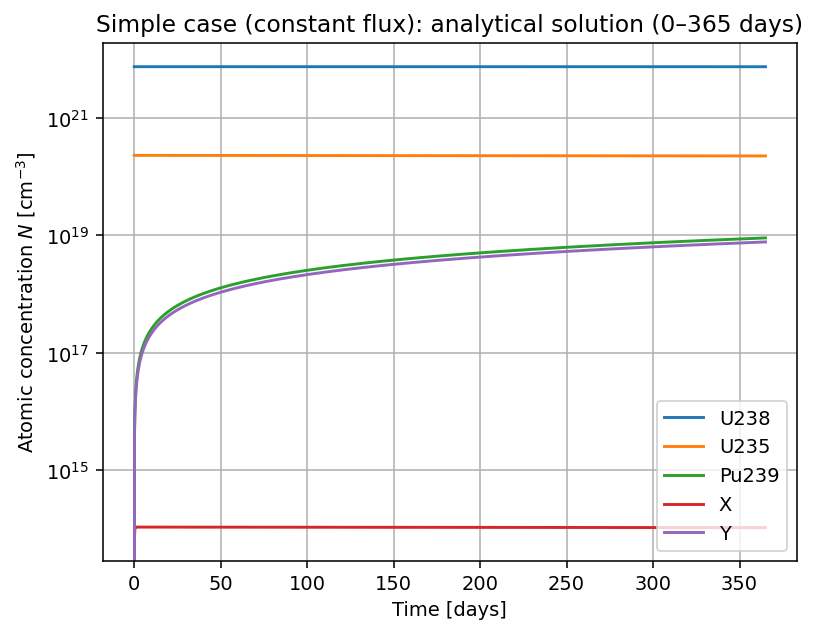

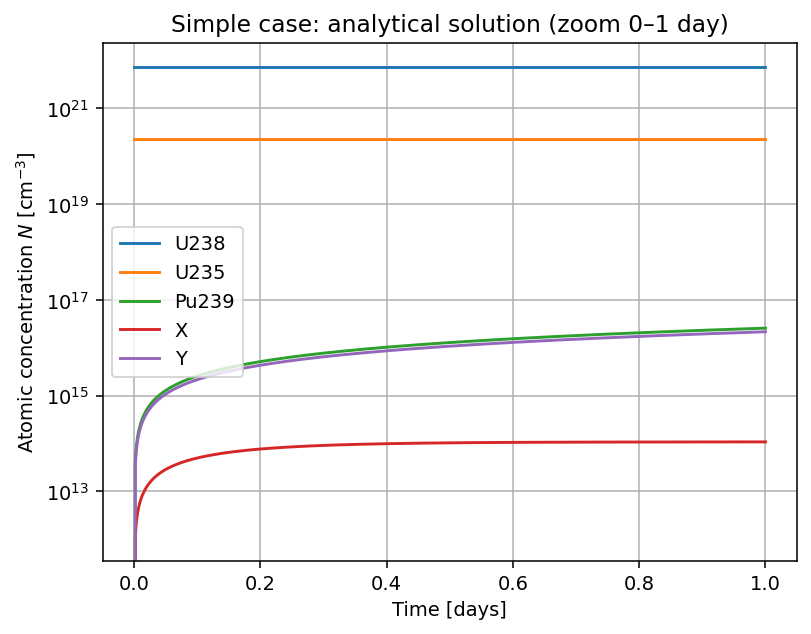


Analytical solution check at t = 1 day:
  U238 : 7.467e+21 cm^-3
  U235 : 2.309e+20 cm^-3
  Pu239: 2.580e+16 cm^-3
  X    : 1.085e+14 cm^-3
  Y    : 2.168e+16 cm^-3
Given check (image): U-235=2.31e20, Pu-239=2.58e16, X=1.08e14, Y=2.17e16 (cm^-3)


In [5]:

# -----------------------
# Simple system: constant flux (Questions 2–4)
# -----------------------
PHI_CONST = 1.0e13  # [n/(cm^2 s)]

# State vector order:
#   0: U238, 1: U235, 2: Pu239, 3: X, 4: Y
state_names = ["U238", "U235", "Pu239", "X", "Y"]

def build_A_simple(phi: float) -> np.ndarray:
    """Build depletion matrix A [1/s] for the SIMPLE model (constant flux)."""
    A = np.zeros((5,5), dtype=float)
    iU238, iU235, iPu, iX, iY = 0,1,2,3,4

    A[iU238, iU238] = -phi * sig_a["U238"]
    A[iU235, iU235] = -phi * sig_a["U235"]

    A[iPu, iU238] = +phi * sig_c["U238"]
    A[iPu, iPu]   = -phi * sig_a["Pu239"]

    A[iX, iU235] = +phi * FY_X * sig_f["U235"]
    A[iX, iX]    = -(LAMBDA_X + phi * sig_a["X"])

    A[iY, iU235] = +phi * FY_Y * sig_f["U235"]
    A[iY, iY]    = -phi * sig_a["Y"]

    return A

def analytic_solution_simple(t_s: np.ndarray, phi: float, N0: dict) -> np.ndarray:
    """Analytical solution N(t) for the SIMPLE model (constant flux).

    Returns array with shape (5, len(t_s)) in order [U238, U235, Pu239, X, Y].
    Concentrations are [cm^-3], time is [s].
    """
    t_s = np.asarray(t_s, dtype=float)

    a238 = phi * sig_a["U238"]
    a235 = phi * sig_a["U235"]
    apu  = phi * sig_a["Pu239"]
    aX   = LAMBDA_X + phi * sig_a["X"]
    aY   = phi * sig_a["Y"]

    N238_0, N235_0 = N0["U238"], N0["U235"]
    Npu_0, NX_0, NY_0 = N0["Pu239"], N0["X"], N0["Y"]

    N238 = N238_0 * np.exp(-a238 * t_s)
    N235 = N235_0 * np.exp(-a235 * t_s)

    b = phi * sig_c["U238"]
    Npu = Npu_0 * np.exp(-apu*t_s) + (b*N238_0/(apu-a238))*(np.exp(-a238*t_s) - np.exp(-apu*t_s))

    pX = phi * FY_X * sig_f["U235"]
    NX = NX_0*np.exp(-aX*t_s) + (pX*N235_0/(aX-a235))*(np.exp(-a235*t_s) - np.exp(-aX*t_s))

    pY = phi * FY_Y * sig_f["U235"]
    NY = NY_0*np.exp(-aY*t_s) + (pY*N235_0/(aY-a235))*(np.exp(-a235*t_s) - np.exp(-aY*t_s))

    return np.vstack([N238, N235, Npu, NX, NY])

A_simple = build_A_simple(PHI_CONST)
print("A (simple case) [1/s]:")
np.set_printoptions(precision=5, suppress=False)
print(A_simple)

# Analytical plots
t_days = np.linspace(0.0, 365.0, 2000)
t_s = t_days * 24*3600
N_ana = analytic_solution_simple(t_s, PHI_CONST, N0)

plt.figure()
for i, name in enumerate(state_names):
    plt.semilogy(t_days, N_ana[i,:], label=name)
plt.xlabel("Time [days]")
plt.ylabel(r"Atomic concentration $N$ [cm$^{-3}$]")
plt.title("Simple case (constant flux): analytical solution (0–365 days)")
plt.grid(True, which="both")
plt.legend()
plt.show()

# Zoom 0–1 day
t_days_zoom = np.linspace(0.0, 1.0, 600)
t_s_zoom = t_days_zoom * 24*3600
N_zoom = analytic_solution_simple(t_s_zoom, PHI_CONST, N0)

plt.figure()
for i, name in enumerate(state_names):
    plt.semilogy(t_days_zoom, N_zoom[i,:], label=name)
plt.xlabel("Time [days]")
plt.ylabel(r"Atomic concentration $N$ [cm$^{-3}$]")
plt.title("Simple case: analytical solution (zoom 0–1 day)")
plt.grid(True, which="both")
plt.legend()
plt.show()

# Solution check at 1 day
t1 = 1.0 * 24*3600
N1 = analytic_solution_simple(np.array([t1]), PHI_CONST, N0)[:,0]
print("\nAnalytical solution check at t = 1 day:")
for name, val in zip(state_names, N1):
    print(f"  {name:5s}: {val:.3e} cm^-3")
print("Given check (image): U-235=2.31e20, Pu-239=2.58e16, X=1.08e14, Y=2.17e16 (cm^-3)")


## Question 3 — Numerical solution (dt = 1 min): Forward Euler and Exp3 + relative error

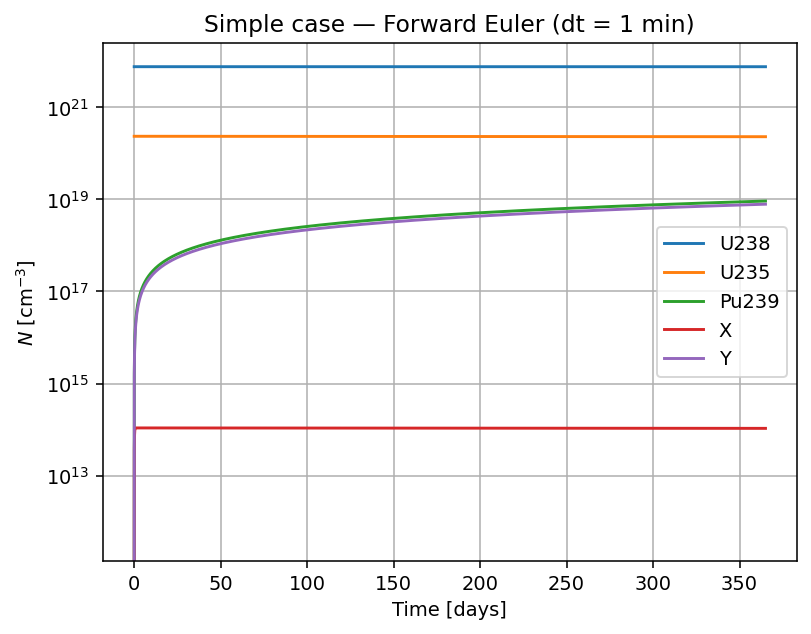

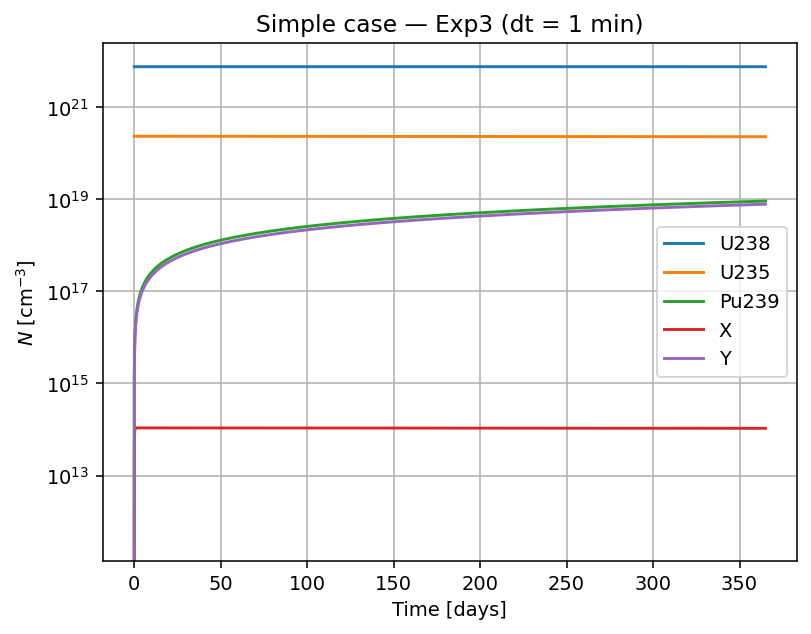

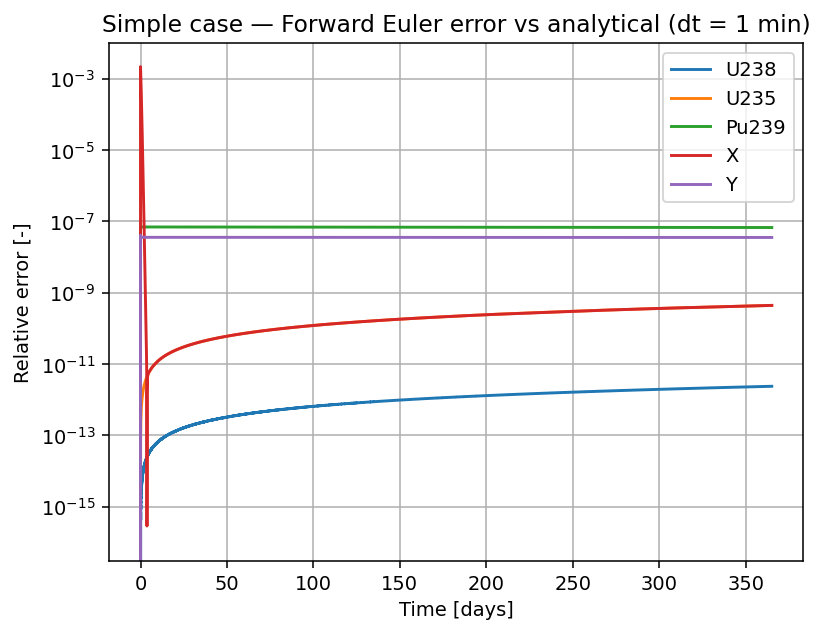

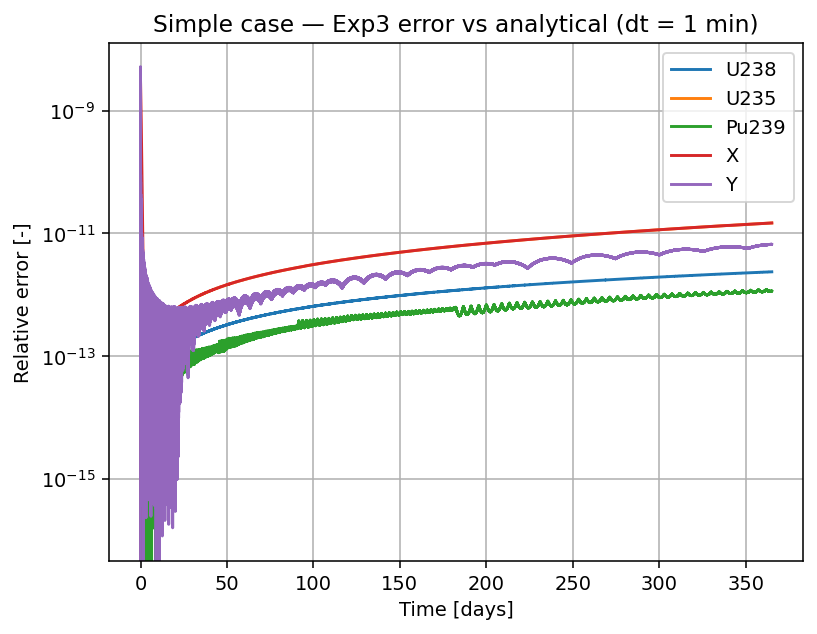


Numerical check at t = 1 day (dt=1 min):
  U238 : Euler=7.467e+21 | Exp3=7.467e+21 | Ref=7.467e+21  (cm^-3)
  U235 : Euler=2.309e+20 | Exp3=2.309e+20 | Ref=2.309e+20  (cm^-3)
  Pu239: Euler=2.580e+16 | Exp3=2.580e+16 | Ref=2.580e+16  (cm^-3)
  X    : Euler=1.085e+14 | Exp3=1.085e+14 | Ref=1.085e+14  (cm^-3)
  Y    : Euler=2.168e+16 | Exp3=2.168e+16 | Ref=2.168e+16  (cm^-3)


In [9]:

def propagate_forward_euler(A: np.ndarray, N0_vec: np.ndarray, dt_s: float, t_end_s: float):
    """Forward Euler propagation for dN/dt = A N."""
    n_steps = int(np.ceil(t_end_s/dt_s))
    t = np.linspace(0.0, n_steps*dt_s, n_steps+1)
    N = np.zeros((len(N0_vec), n_steps+1), dtype=float)
    N[:,0] = N0_vec
    for k in range(n_steps):
        N[:,k+1] = N[:,k] + dt_s*(A @ N[:,k])
    return t, N

def step_matrix_exp3(A: np.ndarray, N: np.ndarray, dt_s: float):
    """One time step using 3rd-order Taylor approximation of exp(A dt)."""
    B = A * dt_s
    v1 = B @ N
    v2 = B @ v1
    v3 = B @ v2
    return N + v1 + 0.5*v2 + (1.0/6.0)*v3

def propagate_matrix_exp3(A: np.ndarray, N0_vec: np.ndarray, dt_s: float, t_end_s: float):
    """Time propagation using Exp3 (3rd-order matrix exponential, Taylor)."""
    n_steps = int(np.ceil(t_end_s/dt_s))
    t = np.linspace(0.0, n_steps*dt_s, n_steps+1)
    N = np.zeros((len(N0_vec), n_steps+1), dtype=float)
    N[:,0] = N0_vec
    for k in range(n_steps):
        N[:,k+1] = step_matrix_exp3(A, N[:,k], dt_s)
    return t, N

# Initial vector in chosen order
N0_vec = np.array([N0["U238"], N0["U235"], N0["Pu239"], N0["X"], N0["Y"]], dtype=float)

dt = 60.0
t_end = 365.0*24*3600

t_eu, N_eu = propagate_forward_euler(A_simple, N0_vec, dt, t_end)
t_me, N_me = propagate_matrix_exp3(A_simple, N0_vec, dt, t_end)

N_ref = analytic_solution_simple(t_eu, PHI_CONST, N0)

# Concentration plots
plt.figure()
for i, name in enumerate(state_names):
    plt.semilogy(t_eu/(24*3600), N_eu[i,:], label=name)
plt.xlabel("Time [days]")
plt.ylabel(r"$N$ [cm$^{-3}$]")
plt.title("Simple case — Forward Euler (dt = 1 min)")
plt.grid(True, which="both")
plt.legend()
plt.show()

plt.figure()
for i, name in enumerate(state_names):
    plt.semilogy(t_me/(24*3600), N_me[i,:], label=name)
plt.xlabel("Time [days]")
plt.ylabel(r"$N$ [cm$^{-3}$]")
plt.title("Simple case — Exp3 (dt = 1 min)")
plt.grid(True, which="both")
plt.legend()
plt.show()

# Relative error plots
eps = 1e-300
rel_err_eu = np.abs(N_eu - N_ref) / (np.abs(N_ref) + eps)
rel_err_me = np.abs(N_me - N_ref) / (np.abs(N_ref) + eps)

plt.figure()
for i, name in enumerate(state_names):
    plt.semilogy(t_eu/(24*3600), rel_err_eu[i,:], label=name)
plt.xlabel("Time [days]")
plt.ylabel("Relative error [-]")
plt.title("Simple case — Forward Euler error vs analytical (dt = 1 min)")
plt.grid(True, which="both")
plt.legend()
plt.show()

plt.figure()
for i, name in enumerate(state_names):
    plt.semilogy(t_me/(24*3600), rel_err_me[i,:], label=name)
plt.xlabel("Time [days]")
plt.ylabel("Relative error [-]")
plt.title("Simple case — Exp3 error vs analytical (dt = 1 min)")
plt.grid(True, which="both")
plt.legend()
plt.show()

# 1-day check
idx_1day = int((1.0*24*3600)/dt)
print("\nNumerical check at t = 1 day (dt=1 min):")
for i, name in enumerate(state_names):
    print(f"  {name:5s}: Euler={N_eu[i,idx_1day]:.3e} | Exp3={N_me[i,idx_1day]:.3e} | Ref={N_ref[i,idx_1day]:.3e}  (cm^-3)")


## Question 4 — Convergence study (QoI = X after 1 day, dt from 1 min to 6 h)

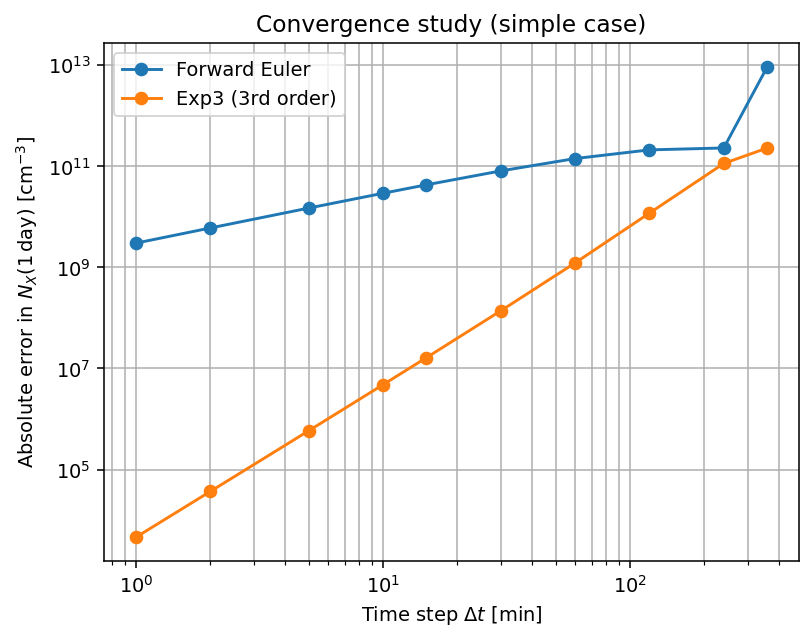

Estimated slope (Euler) ~ 1.06  (expected ~1)
Estimated slope (Exp3)  ~ 3.06  (expected ~3)


In [7]:

def qoi_error_at_1day(method: str, dt_s: float):
    """Absolute error in QoI = N_X(1 day) for a given method and time step."""
    t_end_local = 1.0 * 24*3600
    if method == "euler":
        t, N = propagate_forward_euler(A_simple, N0_vec, dt_s, t_end_local)
    elif method == "exp3":
        t, N = propagate_matrix_exp3(A_simple, N0_vec, dt_s, t_end_local)
    else:
        raise ValueError("method must be 'euler' or 'exp3'")
    NX_num = np.interp(t_end_local, t, N[3,:])
    NX_ref = analytic_solution_simple(np.array([t_end_local]), PHI_CONST, N0)[3,0]
    return abs(NX_num - NX_ref)

dt_list = np.array([60, 120, 300, 600, 900, 1800, 3600, 7200, 14400, 21600], dtype=float)
err_eu = np.array([qoi_error_at_1day("euler", dt_i) for dt_i in dt_list])
err_me = np.array([qoi_error_at_1day("exp3", dt_i) for dt_i in dt_list])

plt.figure()
plt.loglog(dt_list/60.0, err_eu, marker="o", label="Forward Euler")
plt.loglog(dt_list/60.0, err_me, marker="o", label="Exp3 (3rd order)")
plt.xlabel(r"Time step $\Delta t$ [min]")
plt.ylabel(r"Absolute error in $N_X(1\,\mathrm{day})$ [cm$^{-3}$]")
plt.title("Convergence study (simple case)")
plt.grid(True, which="both")
plt.legend()
plt.show()

def fit_slope(dt, err):
    x = np.log(dt)
    y = np.log(err)
    m, _ = np.polyfit(x, y, 1)
    return m

print(f"Estimated slope (Euler) ~ {fit_slope(dt_list, err_eu):.2f}  (expected ~1)")
print(f"Estimated slope (Exp3)  ~ {fit_slope(dt_list, err_me):.2f}  (expected ~3)")


## Questions 5–6 — Complex system (constant power density): flux evolution + compositions

Computed Phi(0) = 1.40570e+15 n/(cm^2 s)  (given check: 1.40574e15)

A at first step (complex case) [1/s]:
[[-7.02852e-09  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00 -9.55879e-08  0.00000e+00  0.00000e+00  0.00000e+00]
 [ 5.62282e-09  0.00000e+00 -3.16283e-07  0.00000e+00  0.00000e+00]
 [ 8.43422e-11  4.72316e-09  1.21453e-08 -7.04991e-03  0.00000e+00]
 [ 2.72707e-09  1.52716e-07  3.92697e-07  0.00000e+00 -7.02852e-08]]


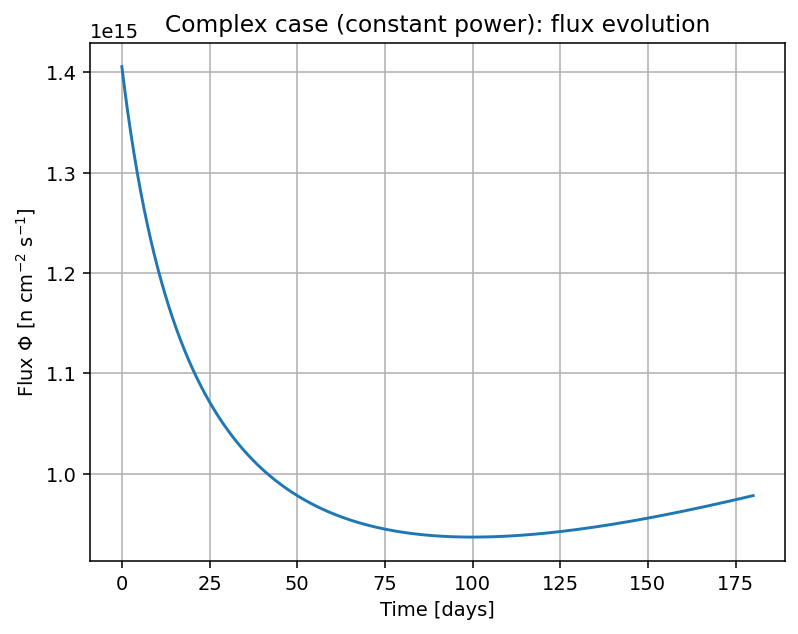

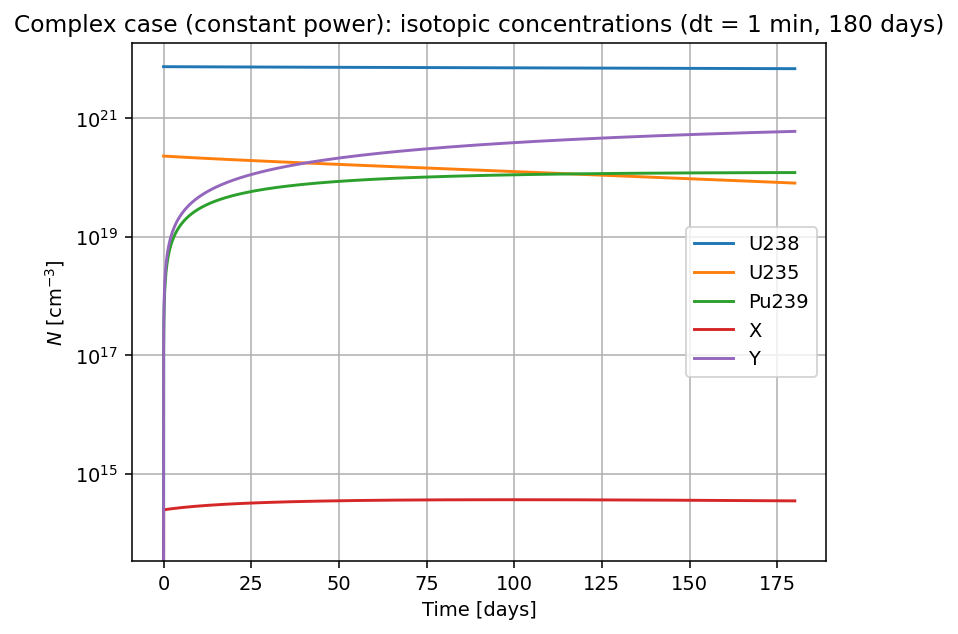

In [8]:

P0 = 937.5  # [W/cm^3]

def flux_from_power(N_vec: np.ndarray, P0_W_cm3: float) -> float:
    """Compute flux φ [n/(cm^2 s)] enforcing constant power density P0 [W/cm^3]."""
    N238, N235, Npu = N_vec[0], N_vec[1], N_vec[2]
    denom = (
        kappa_J["U235"]  * sig_f["U235"]  * N235 +
        kappa_J["U238"]  * sig_f["U238"]  * N238 +
        kappa_J["Pu239"] * sig_f["Pu239"] * Npu
    )
    return P0_W_cm3 / max(denom, 1e-300)

def build_A_complex(phi: float) -> np.ndarray:
    """Build depletion matrix A [1/s] for constant-power case at given flux phi."""
    A = np.zeros((5,5), dtype=float)
    iU238, iU235, iPu, iX, iY = 0,1,2,3,4

    A[iU238, iU238] = -phi * sig_a["U238"]
    A[iU235, iU235] = -phi * sig_a["U235"]

    A[iPu, iU238] = +phi * sig_c["U238"]
    A[iPu, iPu]   = -phi * sig_a["Pu239"]

    # X from all fissions
    A[iX, iU238] = +phi * FY_X * sig_f["U238"]
    A[iX, iU235] = +phi * FY_X * sig_f["U235"]
    A[iX, iPu]   = +phi * FY_X * sig_f["Pu239"]
    A[iX, iX]    = -(LAMBDA_X + phi * sig_a["X"])

    # Y from all fissions
    A[iY, iU238] = +phi * FY_Y * sig_f["U238"]
    A[iY, iU235] = +phi * FY_Y * sig_f["U235"]
    A[iY, iPu]   = +phi * FY_Y * sig_f["Pu239"]
    A[iY, iY]    = -phi * sig_a["Y"]

    return A

phi0 = flux_from_power(N0_vec, P0)
print(f"Computed Phi(0) = {phi0:.5e} n/(cm^2 s)  (given check: 1.40574e15)")
print("\nA at first step (complex case) [1/s]:")
np.set_printoptions(precision=5, suppress=False)
print(build_A_complex(phi0))

# Integrate with Exp3 for 180 days, dt=1 min
dt = 60.0
t_end = 180.0 * 24*3600
n_steps = int(np.ceil(t_end/dt))

t = np.linspace(0.0, n_steps*dt, n_steps+1)
N = np.zeros((5, n_steps+1), dtype=float)
phi_hist = np.zeros(n_steps+1, dtype=float)

N[:,0] = N0_vec.copy()
phi_hist[0] = flux_from_power(N[:,0], P0)

for k in range(n_steps):
    phi_k = flux_from_power(N[:,k], P0)
    phi_hist[k] = phi_k
    A_k = build_A_complex(phi_k)
    N[:,k+1] = step_matrix_exp3(A_k, N[:,k], dt)

phi_hist[-1] = flux_from_power(N[:,-1], P0)

plt.figure()
plt.plot(t/(24*3600), phi_hist)
plt.xlabel("Time [days]")
plt.ylabel(r"Flux $\Phi$ [n cm$^{-2}$ s$^{-1}$]")
plt.title("Complex case (constant power): flux evolution")
plt.grid(True)
plt.show()

plt.figure()
for i, name in enumerate(state_names):
    plt.semilogy(t/(24*3600), N[i,:], label=name)
plt.xlabel("Time [days]")
plt.ylabel(r"$N$ [cm$^{-3}$]")
plt.title("Complex case (constant power): isotopic concentrations (dt = 1 min, 180 days)")
plt.grid(True, which="both")
plt.legend()
plt.show()
